# Ένας Νέος Τρόπος Πλεξίματος

To πρόβλημα είναι βασισμένο στο θέμα του ΠΔΤΝ: https://pdtn.gr/contests/pdtn25a/tasks/knit

Στόχος της άσκησης είναι να προσεγγίσετε και τις δοσμένες φωτογραφίες με κατάλληλες ευθείες. Υπολογίστε βάρη στο διάστημα 0-100, για την σκουρότητα της κάθε ευθείας ώστε το τελικό αποτέλεσμα να αποδίδει τα χαρακτηριστικά της κάθε μια εικόνας από τις 4 δοσμένες.

Μπορείτε να δείτε το αποτέλεσμα σας στο interface του ΠΔΤΝ και το σκορ που παίρνετε.

In [ ]:
import os
import numpy as np
import torch
import torchvision
from gdown import download
from zipfile import ZipFile

# 1. Κατεβάζουμε όλες τις εικόνες

In [ ]:
def download_and_extract(id, filename, extracted_folder):
    # Κατεβάζουμε το αρχείο zip εάν δεν υπάρχει ήδη
    if not os.path.exists(filename):
        print("Γίνεται φόρτωση του αρχείου",filename)
        download(id=id, output=filename, quiet=False)

    # Εξαγωγή του αρχείου zip εάν ο φάκελος δεν υπάρχει ήδη

    if not os.path.exists(extracted_folder):
        print("Γίνεται αποσυμπίεση των αρχείων...")
        with ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall(extracted_folder)
main_folder = "knit"
download_and_extract('1FuQN05LKMaexSESklGxRr5av1EERGU5w', "knit.zip", main_folder)

# 2. Φορτώνουμε την εικόνα στόχο

Φορτώνουμε την εικόνα που θέλουμε να φτιάξουμε σαν torch.tensor με τιμές ανάμεσα στο 0 και το 1.

Το 1 σημαίνει πολύ σκούρο και το 0 πολύ αχνό.

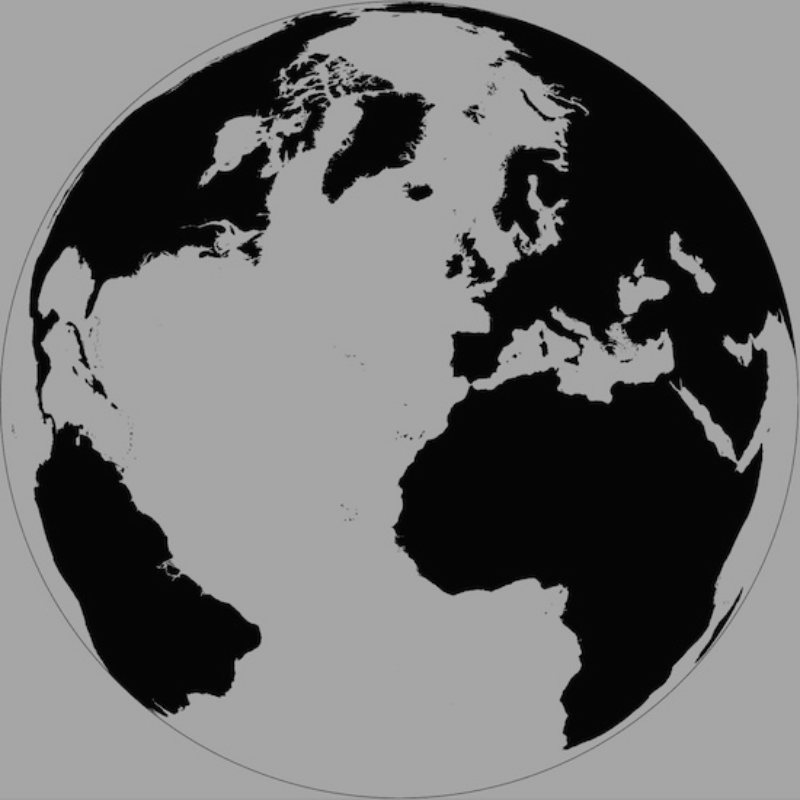

In [ ]:
def readImage(filename, S=800):
    with open(filename, "rb") as f:
        image_bytes = f.read()
    image_tensor = torchvision.io.decode_image(torch.tensor(list(image_bytes)).byte(), mode=torchvision.io.ImageReadMode.GRAY)

    image_tensor = 1 - image_tensor.float() / 255.0
    resize_transform = torchvision.transforms.Resize( (S,S) )
    return resize_transform(image_tensor).squeeze()

def showImage(I):
    return torchvision.transforms.functional.to_pil_image( (1-I).clamp(0,1) )

target = readImage('knit/world.jpg')
# target = readImage('knit/circles.jpg')
# target = readImage('knit/world.jpg')
# target = readImage('knit/eye.jpg')
showImage(target)

# 3. Από γραμμές σε εικόνα

Ορίζουμε μια συνάρτηση `linesToImage` που παίρνει τα βάρη των ευθειών και επιστρέφει την εικόνα που αντιστοιχεί

In [ ]:
N = 200
S = target.shape[0]
R = S//2
i, j = torch.meshgrid(torch.arange(-R, R), torch.arange(-R, R), indexing="ij")
mask = (i**2 + j**2) <= R**2
points = torch.stack((i[mask], j[mask]), dim=-1).float()
angles = torch.arange(N, dtype=torch.float32) * torch.pi / N
rotated_points = points @ torch.stack([torch.cos(angles), -torch.sin(angles)])
rotated_points_line = N * (rotated_points / R).arccos() / torch.pi - (torch.arange(N) % 2)
closest_line = torch.round(rotated_points_line / 2).clamp(0,N//2-1).int()
rows = torch.stack(
    [R * ( (2*torch.arange(N//2) + 0)  * torch.pi / N).cos(),
     R * ( (2*torch.arange(N//2) + 1)  * torch.pi / N).cos()], 1
)

def linesToImage(lines):
    L = lines[closest_line, torch.arange(N) ].clamp(0,1)
    L *= torch.abs( rotated_points - rows[ closest_line, torch.arange(N) % 2 ] ) <= 1
    I = torch.zeros( (S,S) )
    I[mask] = L.sum(-1)
    return I

# 4. Αρχικοποιούμε τα βάρη των ευθειών ως 0

In [ ]:
lines = torch.nn.Parameter(torch.zeros((N//2, N)))


# 5. Βελτιστοποιούμε τα βάρη

Χρησιμοποιήστε την βιβλιοθήκη `pytorch` για να βελτιστοποιήσετε τα βάρη με κάθοδo με βάση την κλίση (gradient descent) για να μοιάζει όσο το δυνατόν περισσότερο η εικόνα που προκύπτει από τις ευθείες στην δοσμένη εικόνα.


In [ ]:
optimizer = torch.optim.Adam([lines], lr=0.0005)
loss_fn = torch.nn.MSELoss()

for step in range(200):
  optimizer.zero_grad()

  output = linesToImage(lines)
  loss = loss_fn(output, target)

  loss.backward()
  optimizer.step()

  print(f"Step {step}, Loss: {loss.item():.4f}")


Step 0, Loss: 0.4088
Step 1, Loss: 0.3891
Step 2, Loss: 0.3700
Step 3, Loss: 0.3517
Step 4, Loss: 0.3341
Step 5, Loss: 0.3173
Step 6, Loss: 0.3011
Step 7, Loss: 0.2857
Step 8, Loss: 0.2711
Step 9, Loss: 0.2572
Step 10, Loss: 0.2440
Step 11, Loss: 0.2316
Step 12, Loss: 0.2199
Step 13, Loss: 0.2088
Step 14, Loss: 0.1985
Step 15, Loss: 0.1889
Step 16, Loss: 0.1799
Step 17, Loss: 0.1715
Step 18, Loss: 0.1638
Step 19, Loss: 0.1566
Step 20, Loss: 0.1500
Step 21, Loss: 0.1438
Step 22, Loss: 0.1382
Step 23, Loss: 0.1331
Step 24, Loss: 0.1283
Step 25, Loss: 0.1240
Step 26, Loss: 0.1200
Step 27, Loss: 0.1164
Step 28, Loss: 0.1131
Step 29, Loss: 0.1100
Step 30, Loss: 0.1073
Step 31, Loss: 0.1047
Step 32, Loss: 0.1024
Step 33, Loss: 0.1002
Step 34, Loss: 0.0982
Step 35, Loss: 0.0964
Step 36, Loss: 0.0947
Step 37, Loss: 0.0931
Step 38, Loss: 0.0916
Step 39, Loss: 0.0903
Step 40, Loss: 0.0890
Step 41, Loss: 0.0878
Step 42, Loss: 0.0867
Step 43, Loss: 0.0857
Step 44, Loss: 0.0847
Step 45, Loss: 0.083

# 6. Εξαγωγή των βαρών

Παίρνουμε τα βάρη των ευθειών για υποβολή στο site.
Αντιγράψτε τα νούμερα που προκύπτουν και επικολλήστε τα στο site για υποβολή.

In [ ]:
def getWeights(lines):
    return ('\n'.join( [' '.join(map(str,x)) for x in ((100*lines.T).clamp(0,100.0).int()).tolist()] ))

getWeights(lines)

'0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 1 1 2 2 1 1 0 2 3 2 3 3 3 2 2 3 3 2 1 1 1 1 0 0 0 0 0 0 0 1 1 0 1 1 2 2 3 3 2 3 3 2 3 3 1 1 0 1 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0\n0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 2 2 1 1 0 1 2 2 3 3 3 2 2 3 3 2 2 1 0 1 1 1 0 0 0 0 0 0 1 0 0 2 2 2 2 3 3 2 3 2 2 2 2 1 1 0 2 2 1 1 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0\n0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 0 0 2 2 3 3 3 3 2 2 2 2 2 1 1 0 1 1 0 0 0 0 0 0 0 1 0 0 2 3 2 2 3 3 3 3 2 3 2 2 1 1 2 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0\n8 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 2 3 3 3 3 2 2 2 3 2 2 1 0 0 1 1 0 0 0 0 0 0 1 1 1 1 3 2 2 2 2 2 3 2 2 3 2 1 1 1 2 2 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0\n9 0 3 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 0 0 1 3 3 3 3 3 2 2 2 2 2 2 1 0 1 1 1 0 0 0 0 0 0 1 2 1 3 3 2 2 2 2 3 3 2 3 2 2 1 1 2 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0